In [24]:
#imports
import os
import mne
import matplotlib.pyplot as plt

In [20]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


In [4]:
# Parent folder
DATA_DIR = "/Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0"

# Subject folder
SUBJECT_ID = "S001"
subject_folder = os.path.join(DATA_DIR, SUBJECT_ID)

# EDF file name
edf_filename = "S001R03.edf"


# Full path
edf_path = os.path.join(subject_folder, edf_filename)

print("Loading:", edf_path)



Loading: /Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf


In [5]:
# Load EEG recording
raw = mne.io.read_raw_edf(
    edf_path,
    preload=True
)

# Basic information
print("\n===== FILE INFO =====")
print(raw)

print("\n===== CHANNEL NAMES =====")
print(raw.ch_names)

print("\n===== DATA SHAPE =====")
print(raw.get_data().shape)



Extracting EDF parameters from /Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...

===== FILE INFO =====
<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

===== CHANNEL NAMES =====
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']

===== DATA SHAPE =====
(64, 20000)


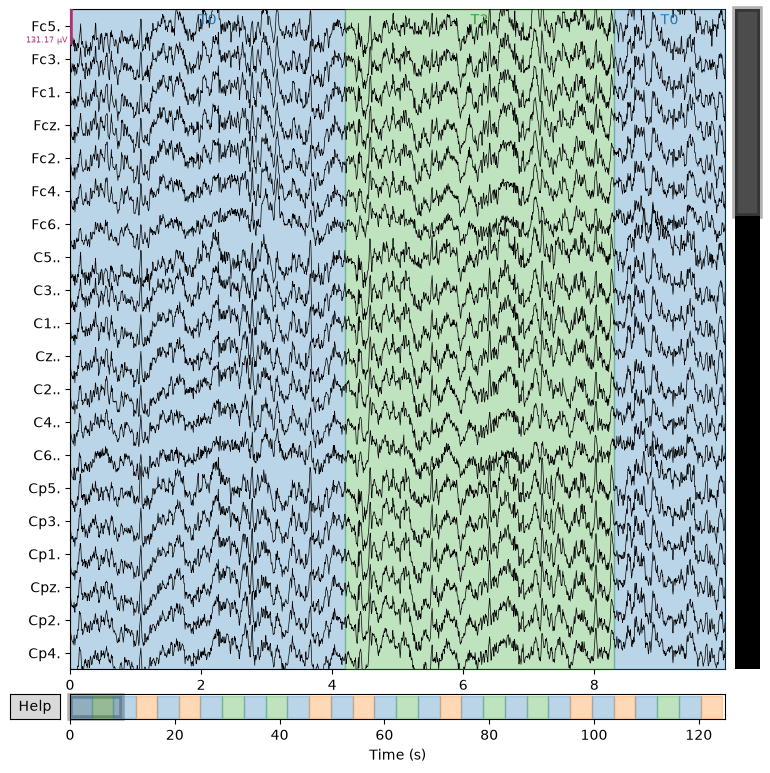

In [22]:
# Interactive EEG viewer
raw.plot(
    duration=10,
    n_channels=20,
    scalings="auto"
)

plt.show()

In [7]:
events, event_id = mne.events_from_annotations(raw)

print("Event IDs:")
print(event_id)

print("\nFirst 10 events:")
print(events[:10])

print("\nAnnotations:")
print(raw.annotations)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event IDs:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

First 10 events:
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]

Annotations:
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


In [8]:
print("Sampling frequency:", raw.info['sfreq'])
print("Number of channels:", len(raw.ch_names))
print("Recording length (s):", raw.times[-1])

print("\nChannel types:")
print(raw.get_channel_types())

Sampling frequency: 160.0
Number of channels: 64
Recording length (s): 124.99375

Channel types:
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [9]:
data = raw.get_data()

print(data.shape)

print("\nFirst 10 samples of first channel:")
print(data[0][:10])

(64, 20000)

First 10 samples of first channel:
[-5.7e-05 -4.9e-05 -5.5e-05 -7.3e-05 -8.7e-05 -7.6e-05 -7.3e-05 -5.4e-05
 -7.4e-05 -8.9e-05]


In [10]:
for ann in raw.annotations[:10]:
    print(ann)

OrderedDict([('onset', np.float64(0.0)), ('duration', np.float64(4.2)), ('description', np.str_('T0')), ('orig_time', datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc)), ('extras', {})])
OrderedDict([('onset', np.float64(4.2)), ('duration', np.float64(4.1)), ('description', np.str_('T2')), ('orig_time', datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc)), ('extras', {})])
OrderedDict([('onset', np.float64(8.3)), ('duration', np.float64(4.2)), ('description', np.str_('T0')), ('orig_time', datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc)), ('extras', {})])
OrderedDict([('onset', np.float64(12.5)), ('duration', np.float64(4.1)), ('description', np.str_('T1')), ('orig_time', datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc)), ('extras', {})])
OrderedDict([('onset', np.float64(16.6)), ('duration', np.float64(4.2)), ('description', np.str_('T0')), ('orig_time', datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.t

In [ ]:
print(events.shape)
print(events[:20])
print(event_id)

(30, 3)
[[    0     0     1]
 [  672     0     3]
 [ 1328     0     1]
 [ 2000     0     2]
 [ 2656     0     1]
 [ 3328     0     2]
 [ 3984     0     1]
 [ 4656     0     3]
 [ 5312     0     1]
 [ 5984     0     3]
 [ 6640     0     1]
 [ 7312     0     2]
 [ 7968     0     1]
 [ 8640     0     2]
 [ 9296     0     1]
 [ 9968     0     3]
 [10624     0     1]
 [11296     0     2]
 [11952     0     1]
 [12624     0     3]]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [ ]:
DATA_DIR = "/Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0"
for subject in range(1, 11):
    subject_id = f"S{subject:03d}"
    run_file = f"{subject_id}R05.edf"
    edf_path = os.path.join(
        DATA_DIR,
        subject_id,
        run_file
    )
    print(f"\nLoading {run_file}")
    raw = mne.io.read_raw_edf(
        edf_path,
        preload=False,
        verbose=False
    )
    print(raw)


Loading S001R05.edf
<RawEDF | S001R05.edf, 64 x 20000 (125.0 s), ~53 KiB, data not loaded>

Loading S002R05.edf
<RawEDF | S002R05.edf, 64 x 19680 (123.0 s), ~53 KiB, data not loaded>

Loading S003R05.edf
<RawEDF | S003R05.edf, 64 x 20000 (125.0 s), ~53 KiB, data not loaded>

Loading S004R05.edf
<RawEDF | S004R05.edf, 64 x 19680 (123.0 s), ~53 KiB, data not loaded>

Loading S005R05.edf
<RawEDF | S005R05.edf, 64 x 19680 (123.0 s), ~53 KiB, data not loaded>

Loading S006R05.edf


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/3792201699.py:21: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


Exception: Encountered invalid byte in at least one annotations channel. You might want to try setting "encoding='latin1'".

In [26]:
DATA_DIR = "/Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0"

for subject in range(1, 11):

    subject_id = f"S{subject:03d}"

    run_file = f"{subject_id}R05.edf"

    path = os.path.join(

        DATA_DIR,

        subject_id,

        run_file

    )

    try:

        raw = mne.io.read_raw_edf(

            path,

            preload=False,

            verbose=False

        )

        print(f"✓ {run_file}")

    except Exception as e:

        print(f"✗ {run_file}")

        print(e)

        break

✓ S001R05.edf
✓ S002R05.edf
✓ S003R05.edf
✓ S004R05.edf
✓ S005R05.edf
✗ S006R05.edf
Encountered invalid byte in at least one annotations channel. You might want to try setting "encoding='latin1'".


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/2167967315.py:21: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


In [27]:

raw = mne.io.read_raw_edf(
    path,
    preload=False,
    encoding="latin1",
    verbose=False
)

print(raw)

<RawEDF | S006R05.edf, 64 x 20000 (125.0 s), ~53 KiB, data not loaded>


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/1857347472.py:1: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


In [31]:
import os
import mne

DATA_DIR = "/Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0"

bad_files = []

for subject in range(1, 110):

    subject_id = f"S{subject:03d}"
    path = os.path.join(
        DATA_DIR,
        subject_id,
        f"{subject_id}R05.edf"
    )

    try:
        raw = mne.io.read_raw_edf(
            path,
            preload=False,
            encoding="latin1",
            verbose=False
        )

    except Exception as e:
        bad_files.append((subject_id, str(e)))

print("Bad files:")
print(bad_files)

/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/43149388.py:18: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/43149388.py:18: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/43149388.py:18: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/43149388.py:18: RuntimeWarning: Number of records from the header does not match the file size (perhaps the re

Bad files:
[]


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/43149388.py:18: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/43149388.py:18: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


In [30]:
import os
import warnings
import mne

DATA_DIR = "/Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0"

warning_subjects = []

for subject in range(1, 110):

    subject_id = f"S{subject:03d}"

    path = os.path.join(
        DATA_DIR,
        subject_id,
        f"{subject_id}R05.edf"
    )

    with warnings.catch_warnings(record=True) as w:

        warnings.simplefilter("always")

        raw = mne.io.read_raw_edf(
            path,
            preload=False,
            encoding="latin1",
            verbose=False
        )

        if len(w) > 0:
            warning_subjects.append(subject_id)

print(warning_subjects)

['S006', 'S009', 'S011', 'S013', 'S019', 'S020', 'S021', 'S028', 'S058', 'S059', 'S060', 'S061', 'S062', 'S063', 'S066', 'S068', 'S071', 'S072', 'S073', 'S074', 'S075', 'S076', 'S077', 'S078', 'S079', 'S080', 'S081', 'S082', 'S083', 'S084', 'S085', 'S086', 'S087', 'S088', 'S089', 'S090', 'S091', 'S092', 'S093', 'S094', 'S095', 'S096', 'S097', 'S098', 'S099', 'S100', 'S101', 'S102', 'S103', 'S104', 'S105', 'S106', 'S107', 'S108', 'S109']


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/436001131.py:27: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/436001131.py:27: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/436001131.py:27: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/436001131.py:27: RuntimeWarning: Number of records from the header does not match the file size (perhaps th

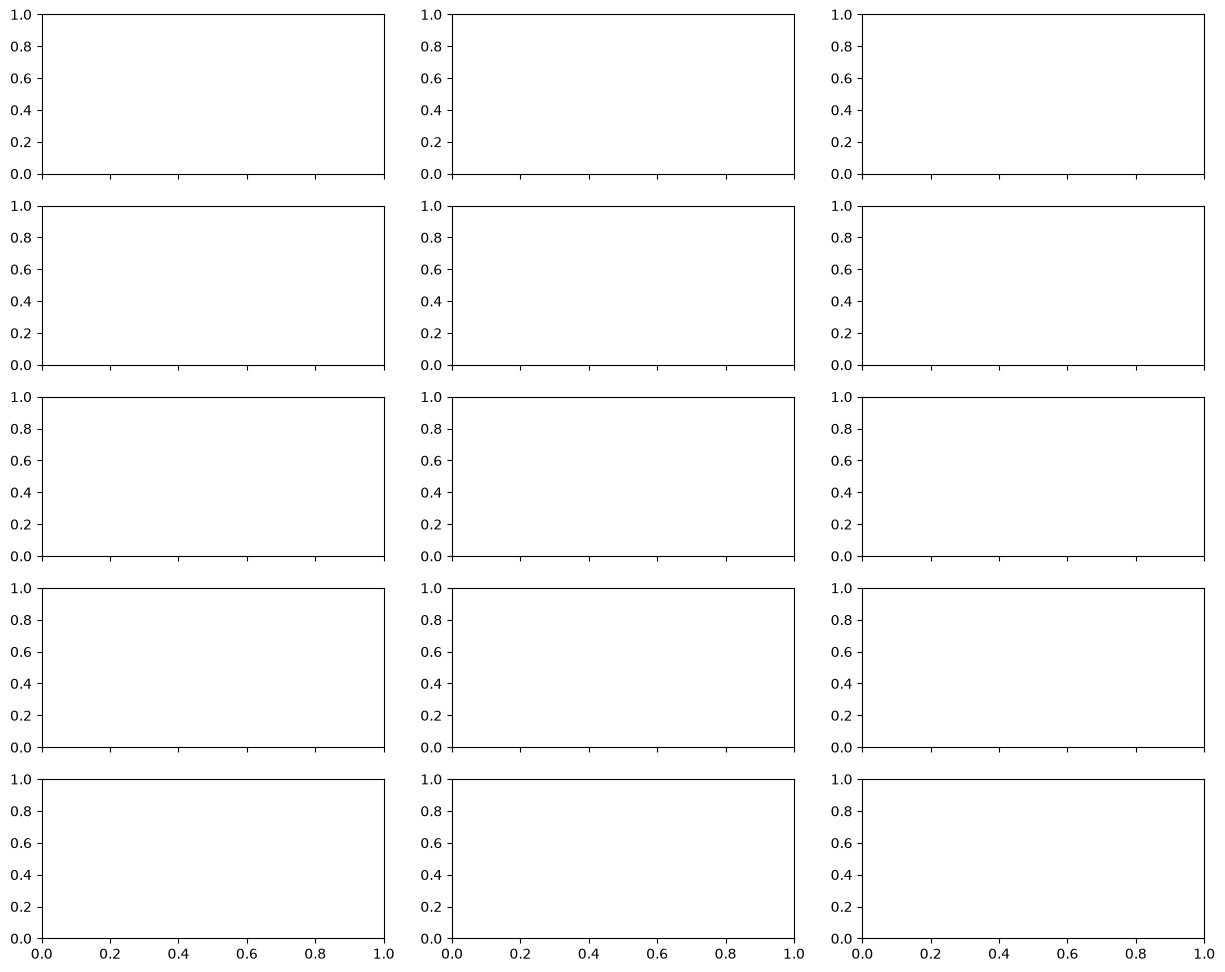

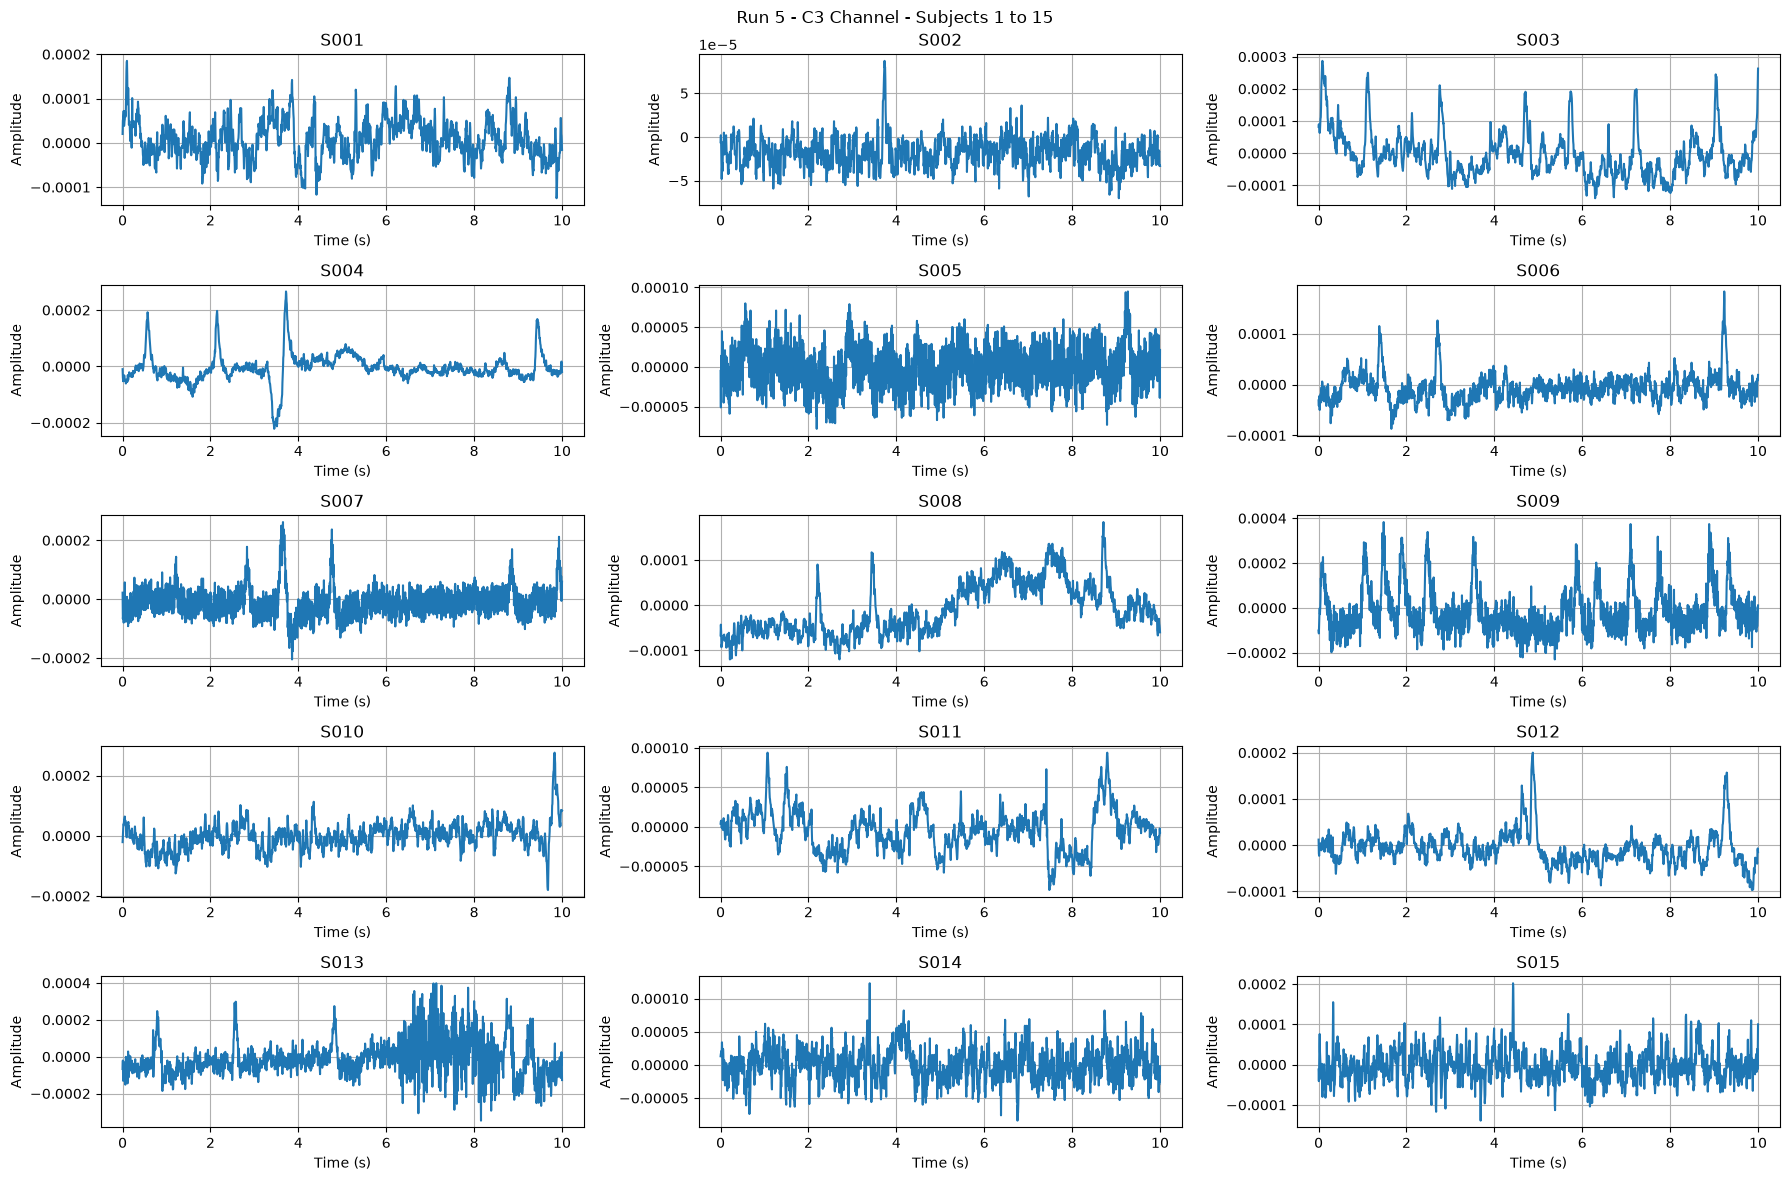

In [ ]:


import os
import mne
import matplotlib.pyplot as plt

DATA_DIR = "/Users/prajwalnara/Documents/EEG-motor-imagery/dataset/physionet.org/files/eegmmidb/1.0.0"

subjects = range(1, 16)

fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(18, 12)
)

axes = axes.flatten()

for i, subject in enumerate(subjects):

    subject_id = f"S{subject:03d}"

    edf_path = os.path.join(
        DATA_DIR,
        subject_id,
        f"{subject_id}R05.edf"
    )

    raw = mne.io.read_raw_edf(
        edf_path,
        preload=False,
        encoding="latin1",
        verbose=False
    )

    # Find the C3 channel name
    c3_channel = None

    for ch in raw.ch_names:
        if "C3" in ch.upper():
            c3_channel = ch
            break

    if c3_channel is None:
        print(f"C3 not found for {subject_id}")
        continue

    # Get EEG data from C3
    data = raw.get_data(picks=[c3_channel])

    # Time axis
    times = raw.times

    # Plot only first 10 seconds
    mask = times <= 10

    axes[i].plot(
        times[mask],
        data[0, mask]
    )

    axes[i].set_title(subject_id)
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

plt.suptitle("Run 5 - C3 Channel - Subjects 1 to 15")
plt.tight_layout()
plt.show()

Now we filter the first 10 signals and check the sanity of the filtered signal also 

In [45]:
#Code for filtering the signal

from pathlib import Path
import mne
import os

RAW_DIR = Path("/Users/prajwalnara/Documents/EEG-motor-imagery/data/raw/physionet.org/files/eegmmidb/1.0.0")
FILTERED_DIR = Path("/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered")

FILTERED_DIR.mkdir(parents=True, exist_ok=True)

SUBJECTS = [f"S{i:03d}" for i in range(1, 11)]
RUNS = {"R03", "R04", "R07", "R08", "R11", "R12"}

for subject in SUBJECTS:

    subject_dir = RAW_DIR / subject
    if not subject_dir.exists():
        print(f"Missing {subject}")
        continue

    output_subject_dir = FILTERED_DIR / subject
    output_subject_dir.mkdir(exist_ok=True)

    for edf_file in subject_dir.glob("*.edf"):

        run = edf_file.stem[-3:]

        if run not in RUNS:
            continue

        print(f"Filtering {edf_file.name}")

        raw = mne.io.read_raw_edf(
            edf_file,
            preload=True,
            encoding="latin1",
            verbose=False
        )

        raw.filter(
            l_freq=4.0,
            h_freq=40.0,
            fir_design="firwin",
            verbose=False
        )

        out_file = (
            output_subject_dir /
            f"{edf_file.stem}_filtered_raw.fif"
        )

        raw.save(
            out_file,
            overwrite=True,
            verbose=False
        )

print("Done.")

Filtering S001R08.edf
Filtering S001R07.edf
Filtering S001R12.edf
Filtering S001R04.edf
Filtering S001R11.edf
Filtering S001R03.edf
Filtering S002R03.edf
Filtering S002R12.edf
Filtering S002R07.edf
Filtering S002R11.edf
Filtering S002R04.edf
Filtering S002R08.edf
Filtering S003R08.edf
Filtering S003R03.edf
Filtering S003R04.edf
Filtering S003R11.edf
Filtering S003R07.edf
Filtering S003R12.edf
Filtering S004R03.edf
Filtering S004R04.edf
Filtering S004R11.edf
Filtering S004R07.edf
Filtering S004R12.edf
Filtering S004R08.edf
Filtering S005R08.edf
Filtering S005R03.edf
Filtering S005R12.edf
Filtering S005R07.edf
Filtering S005R11.edf
Filtering S005R04.edf
Filtering S006R07.edf
Filtering S006R12.edf
Filtering S006R04.edf


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


Filtering S006R11.edf
Filtering S006R03.edf
Filtering S006R08.edf
Filtering S007R08.edf
Filtering S007R11.edf
Filtering S007R04.edf
Filtering S007R12.edf
Filtering S007R07.edf
Filtering S007R03.edf
Filtering S008R03.edf


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


Filtering S008R04.edf
Filtering S008R11.edf
Filtering S008R07.edf
Filtering S008R12.edf
Filtering S008R08.edf


...

Filtering S009R08.edf
Filtering S009R03.edf
Filtering S009R12.edf
Filtering S009R07.edf
Filtering S009R11.edf


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps th

Filtering S009R04.edf
Filtering S010R03.edf
Filtering S010R12.edf
Filtering S010R07.edf


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/250733952.py:34: RuntimeWarning: Number of records from the header does not match the file size (perhaps th

Filtering S010R11.edf
Filtering S010R04.edf
Filtering S010R08.edf
Done.


In [48]:
#Original signal - just to verify 


import mne

raw = mne.io.read_raw_edf(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/raw/physionet.org/files/eegmmidb/1.0.0//S010/S010R07.edf",
    preload=False,
    encoding="latin1"
)

print(raw)
print(raw.times[-1])

Extracting EDF parameters from /Users/prajwalnara/Documents/EEG-motor-imagery/data/raw/physionet.org/files/eegmmidb/1.0.0//S010/S010R07.edf...
Setting channel info structure...
Creating raw.info structure...
<RawEDF | S010R07.edf, 64 x 22080 (138.0 s), ~53 KiB, data not loaded>
137.99375


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/2475348973.py:6: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


In [49]:
#filter signal - just to verify 

filt = mne.io.read_raw_fif(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S010/S010R07_filtered_raw.fif",
    preload=False
)

print(filt)
print(filt.times[-1])

Opening raw data file /Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S010/S010R07_filtered_raw.fif...
Isotrak not found
    Range : 0 ... 22079 =      0.000 ...   137.994 secs
Ready.
<Raw | S010R07_filtered_raw.fif, 64 x 22080 (138.0 s), ~57 KiB, data not loaded>
137.99375


In [50]:
#verifying the annotated 

import mne

raw = mne.io.read_raw_fif(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S010/S010R07_filtered_raw.fif",
    preload=False
)

events, event_id = mne.events_from_annotations(raw)

print(event_id)
print(events.shape)
print(events[:10])

Opening raw data file /Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S010/S010R07_filtered_raw.fif...
Isotrak not found
    Range : 0 ... 22079 =      0.000 ...   137.994 secs
Ready.
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
(30, 3)
[[   0    0    1]
 [ 656    0    3]
 [1312    0    1]
 [1968    0    2]
 [2624    0    1]
 [3280    0    2]
 [3936    0    1]
 [4592    0    3]
 [5248    0    1]
 [5904    0    2]]


Extracting EDF parameters from /Users/prajwalnara/Documents/EEG-motor-imagery/data/raw/physionet.org/files/eegmmidb/1.0.0/S010/S010R07.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 22079  =      0.000 ...   137.994 secs...
Opening raw data file /Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S010/S010R07_filtered_raw.fif...
Isotrak not found
    Range : 0 ... 22079 =      0.000 ...   137.994 secs
Ready.
Reading 0 ... 22079  =      0.000 ...   137.994 secs...
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/3067525144.py:3: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_edf = mne.io.read_raw_edf(


Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/3067525144.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_edf.compute_psd().plot()
/opt/miniconda3/envs/eeg/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_36268/3067525144.py:15: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  filtered.compute_psd().plot()
/opt/miniconda3/envs/eeg/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


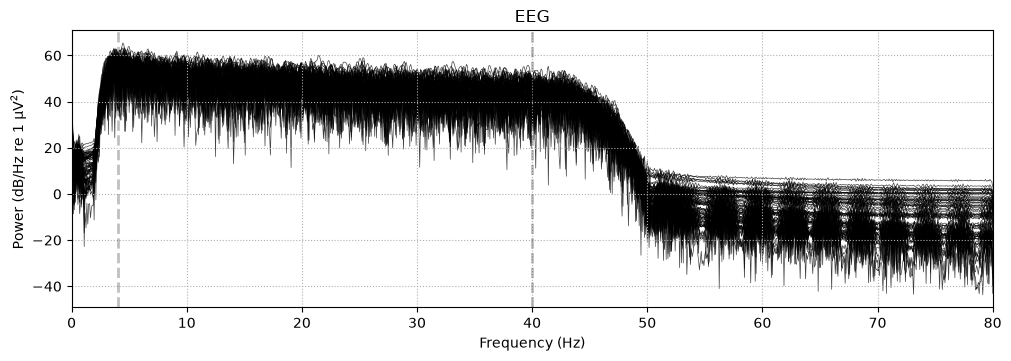

In [51]:
#verifying the filter 

raw_edf = mne.io.read_raw_edf(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/raw/physionet.org/files/eegmmidb/1.0.0/S010/S010R07.edf",
    preload=True,
    encoding="latin1"
)

filtered = mne.io.read_raw_fif(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S010/S010R07_filtered_raw.fif",
    preload=True
)

raw_edf.compute_psd().plot()
filtered.compute_psd().plot()

In [52]:
# 1 last check
print(raw.info['sfreq'])
print(filtered.info['sfreq'])

# 2
print(raw.n_times)
print(filtered.n_times)

# 3
events, event_id = mne.events_from_annotations(filtered)
print(event_id)
print(len(events))

160.0
160.0
22080
22080
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
30


In [53]:
from pathlib import Path
import mne

FILTERED_DIR = Path(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered"
)
EPOCH_DIR = Path(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/epochs"
)
EPOCH_DIR.mkdir(parents=True, exist_ok=True)

SUBJECTS = [f"S{i:03d}" for i in range(1, 11)]
RUNS = {"R04", "R08", "R12"}

REQUIRED_CODES = {"T0", "T1", "T2"}

for subject in SUBJECTS:
    subject_dir = FILTERED_DIR / subject
    if not subject_dir.exists():
        print(f"Skipping {subject}: directory not found")
        continue

    output_subject_dir = EPOCH_DIR / subject
    output_subject_dir.mkdir(exist_ok=True)

    for fif_file in subject_dir.glob("*_filtered_raw.fif"):
        # Extract run code (e.g. "R04") from filename, with a sanity check
        stem_prefix = fif_file.stem.split("_")[0]
        run = stem_prefix[-3:]

        if run not in RUNS:
            continue

        # Sanity check: confirm the extracted run code actually looks right
        if not (run.startswith("R") and run[1:].isdigit()):
            print(f"  Warning: unexpected run code '{run}' parsed from {fif_file.name}, skipping")
            continue

        print(f"Epoching {fif_file.name} (run={run})")

        try:
            raw = mne.io.read_raw_fif(
                fif_file,
                preload=True,
                verbose=False
            )

            events, event_id_raw = mne.events_from_annotations(raw, verbose=False)

            # Guard against missing event codes (e.g. truncated recording)
            if not REQUIRED_CODES.issubset(event_id_raw.keys()):
                print(
                    f"  Skipping {fif_file.name}: missing event codes "
                    f"(found {sorted(event_id_raw.keys())}, need {sorted(REQUIRED_CODES)})"
                )
                continue

            event_id = {
                "rest": event_id_raw["T0"],
                "left": event_id_raw["T1"],
                "right": event_id_raw["T2"],
            }

            # tmin=0, tmax=4.0 -> matches the actual ~4s trial duration
            # confirmed from the .event files (T1/T2 duration ~4.1s, T0 ~4.2s).
            # Change deliberately (and note why in docs/decisions.md) if you
            # want to exclude reaction-time lag at trial onset.
            epochs = mne.Epochs(
                raw,
                events,
                event_id=event_id,
                tmin=0.0,
                tmax=4.0,
                baseline=None,
                preload=True,
                verbose=False,
            )

            if len(epochs) == 0:
                print(f"  Warning: 0 epochs extracted from {fif_file.name}, skipping save")
                continue

            out_file = (
                output_subject_dir
                / f"{fif_file.stem.replace('_filtered_raw', '')}_epo.fif"
            )
            epochs.save(out_file, overwrite=True, verbose=False)
            print(f"  Saved {len(epochs)} epochs -> {out_file.name}")

        except Exception as e:
            print(f"  ERROR processing {fif_file.name}: {e}")
            continue

print("Epoch extraction complete.")

Epoching S001R04_filtered_raw.fif (run=R04)
  Saved 30 epochs -> S001R04_epo.fif
Epoching S001R12_filtered_raw.fif (run=R12)
  Saved 30 epochs -> S001R12_epo.fif
Epoching S001R08_filtered_raw.fif (run=R08)
  Saved 30 epochs -> S001R08_epo.fif
Epoching S002R04_filtered_raw.fif (run=R04)
  Saved 30 epochs -> S002R04_epo.fif
Epoching S002R12_filtered_raw.fif (run=R12)
  Saved 30 epochs -> S002R12_epo.fif
Epoching S002R08_filtered_raw.fif (run=R08)
  Saved 30 epochs -> S002R08_epo.fif
Epoching S003R04_filtered_raw.fif (run=R04)
  Saved 30 epochs -> S003R04_epo.fif
Epoching S003R12_filtered_raw.fif (run=R12)
  Saved 30 epochs -> S003R12_epo.fif
Epoching S003R08_filtered_raw.fif (run=R08)
  Saved 30 epochs -> S003R08_epo.fif
Epoching S004R04_filtered_raw.fif (run=R04)
  Saved 30 epochs -> S004R04_epo.fif
Epoching S004R12_filtered_raw.fif (run=R12)
  Saved 30 epochs -> S004R12_epo.fif
Epoching S004R08_filtered_raw.fif (run=R08)
  Saved 30 epochs -> S004R08_epo.fif
Epoching S005R04_filtered_ra

In [54]:
#checks on epochs task
import mne

epochs = mne.read_epochs(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/epochs/S001/S001R04_epo.fif",
    preload=False
)

print(epochs)
print(epochs.get_data().shape)

Reading /Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/epochs/S001/S001R04_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...    4000.00 ms
        0 CTF compensation matrices available
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 30 events (all good), 0 – 4 s (baseline off), ~57 KiB, data not loaded,
 'rest': 15
 'left': 8
 'right': 7>
Loading data for 30 events and 641 original time points ...
(30, 64, 641)


In [56]:
#epoch class balance 
import numpy as np

labels = epochs.events[:, -1]

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(u, c)

print(epochs.times[0])
print(epochs.times[-1])

1 15
2 8
3 7
0.0
4.0


In [58]:
#extracted vs expected events 
raw = mne.io.read_raw_fif(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S001/S001R04_filtered_raw.fif",
    preload=False
)

events, event_id = mne.events_from_annotations(raw)

print(len(events))
print(len(epochs))

from collections import Counter

print(Counter(raw.annotations.description))

Opening raw data file /Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/filtered/S001/S001R04_filtered_raw.fif...
Isotrak not found
    Range : 0 ... 19999 =      0.000 ...   124.994 secs
Ready.
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
30
30
Counter({np.str_('T0'): 15, np.str_('T1'): 8, np.str_('T2'): 7})


In [60]:
#verification 

from pathlib import Path
from collections import Counter
import mne

EPOCH_DIR = Path(
    "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/epochs"
)

total_counts = Counter()

for epo_file in EPOCH_DIR.rglob("*_epo.fif"):

    epochs = mne.read_epochs(
        epo_file,
        preload=False,
        verbose=False
    )

    # Map numeric event codes back to names
    inverse_event_id = {
        v: k for k, v in epochs.event_id.items()
    }

    labels = [
        inverse_event_id[event_code]
        for event_code in epochs.events[:, 2]
    ]

    total_counts.update(labels)

print("\nDataset Summary")
print("-" * 30)

for cls in ["rest", "left", "right"]:
    print(f"{cls:>6}: {total_counts[cls]}")

print("-" * 30)
print(f" Total: {sum(total_counts.values())}")


Dataset Summary
------------------------------
  rest: 450
  left: 230
 right: 220
------------------------------
 Total: 900


In [11]:
event_id_map = np.load("/Users/prajwalnara/Documents/EEG-motor-imagery/data/features/Band_power/S001/S001_event_id.npy", allow_pickle=True).item()
print(event_id_map)

{'rest': 1, 'left': 2, 'right': 3}
